<a href="https://colab.research.google.com/github/PradeepTiwari12/deep-learning/blob/main/transfer_learning_feature_extraction(data_augmentation)_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:12<00:00, 89.7MB/s]



In [4]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [5]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [6]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [8]:
conv_base.trainable = False

In [11]:
from keras.utils import array_to_img, img_to_array, load_img
from keras import layers, Sequential

In [13]:
!pip install tf-keras

In [25]:
from tf_keras.preprocessing.image import ImageDataGenerator
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
  shear_range=0.2,
        zoom_range=0.2,
       horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
 'train',
 target_size=(150, 150),
batch_size=batch_size,
 class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
'test',
 target_size=(150, 150),
 batch_size=batch_size,
class_mode='binary')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [26]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [27]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 131ms/step - accuracy: 0.9537 - loss: 0.3431 - val_accuracy: 0.9480 - val_loss: 0.1806
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 124ms/step - accuracy: 0.9780 - loss: 0.0768 - val_accuracy: 0.9512 - val_loss: 0.1728
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 124ms/step - accuracy: 0.9875 - loss: 0.0443 - val_accuracy: 0.9504 - val_loss: 0.2010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 124ms/step - accuracy: 0.9912 - loss: 0.0259 - val_accuracy: 0.9528 - val_loss: 0.2573
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 124ms/step - accuracy: 0.9934 - loss: 0.0236 - val_accuracy: 0.9506 - val_loss: 0.2882
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 124ms/step - accuracy: 0.9926 - loss: 0.0300 - val_accuracy: 0.9516 - val_loss: 0.2803
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 124ms/step - accuracy: 0.9911 - loss: 0.0337 - val_accuracy: 0.9530 - val_loss: 0.3262
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 124ms/step - accuracy: 0.9944 - loss: 0

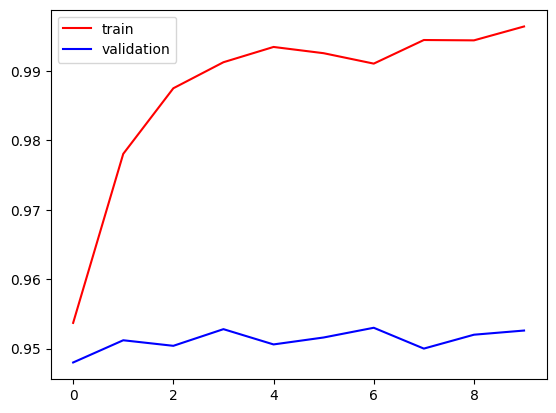

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

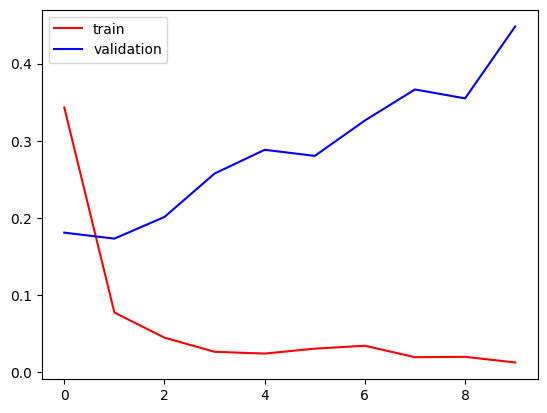

In [29]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()